# Movie Review Sentiment Analysis Using LSTM

## Deep Learning Project

This project uses a Long Short-Term Memory (LSTM) neural network to classify movie reviews as Positive or Negative.

The IMDB Movie Review dataset is used for training and testing the model.

## Problem Statement

Nowadays, a large amount of information is available in the form of online movie reviews. 
Manually reading and analyzing thousands of reviews is difficult and time-consuming.

The objective of this project is to develop a Deep Learning model that can automatically classify 
movie reviews into two categories:

- Positive
- Negative

In this project, Natural Language Processing (NLP) techniques are used to preprocess the movie reviews, 
and an LSTM-based neural network is used to learn patterns from the text and predict the sentiment.

## Objectives

The main objectives of this project are:

1. To load and understand the IMDB movie review dataset.
2. To preprocess the text reviews.
3. To convert text into numerical sequences.
4. To make all sequences the same length using padding.
5. To build an LSTM-based Deep Learning model.
6. To train the model using movie reviews.
7. To evaluate the model using test data.
8. To visualize training accuracy and loss.
9. To generate a confusion matrix and classification report.
10. To predict the sentiment of new movie reviews.

## Dataset Description

The dataset used in this project is the IMDB Movie Review Dataset.

The dataset contains 50,000 movie reviews.

Each review belongs to one of two sentiment classes:

- Positive
- Negative

The dataset contains two columns:

- review: The text of the movie review.
- sentiment: The sentiment label of the review.

The dataset is balanced:

- 25,000 Positive reviews
- 25,000 Negative reviews

For this project, the dataset is divided into training and testing data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


In [2]:
data = pd.read_csv("IMDB Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print("Number of reviews:", len(data))

print("\nColumn names:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nSentiment distribution:")
print(data["sentiment"].value_counts())

Number of reviews: 50000

Column names:
['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


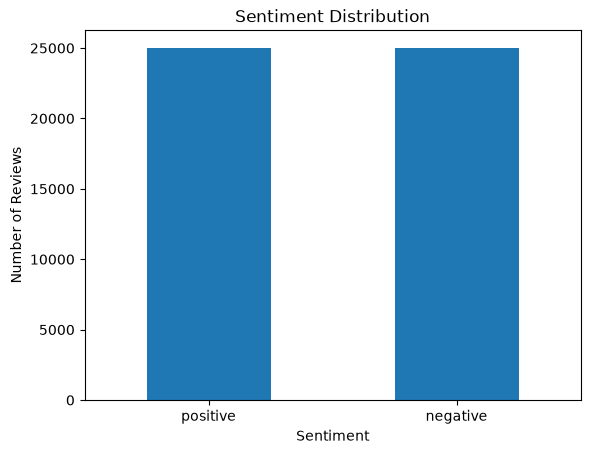

In [4]:
data["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.show()

## Converting Sentiment Labels

Machine Learning models work with numerical values.

Therefore, the sentiment labels are converted into numerical values:

- Negative → 0
- Positive → 1

In [5]:
data["sentiment"] = data["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(data["sentiment"].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


## Text Preprocessing

Movie reviews may contain HTML tags such as `<br />`.

Before sending the reviews to the model, unnecessary HTML tags are removed.

Text is also converted to lowercase 

In [6]:
def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["review"] = data["review"].apply(clean_text)

print(data["review"].iloc[0])

one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldn t dare forget pretty pi

In [7]:
X = data["review"]
y = data["sentiment"]

print("Total reviews:", len(X))
print("Total labels:", len(y))

Total reviews: 50000
Total labels: 50000


## Train-Test Split

The dataset is divided into two parts:

- 80% training data
- 20% testing data


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 40000
Testing reviews: 10000


## Tokenization

A computer cannot directly process normal English sentences.

Therefore, the words in the reviews are converted into numerical values.

This process is called tokenization.

In this project, a vocabulary of the 10,000 most frequently used words is considered.

In [9]:
vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Tokenization completed!")

print("\nFirst review:")
print(X_train.iloc[0][:300])

print("\nFirst review as sequence:")
print(X_train_sequences[0][:20])

Tokenization completed!

First review:
i caught this little gem totally by accident back in or i was at a revival theatre to see two old silly sci fi movies the theatre was packed full and with no warning they showed a bunch of sci fi short spoofs to get us in the mood most were somewhat amusing but this came on and within seconds the au

First review as sequence:
[10, 1031, 11, 121, 1480, 453, 34, 1592, 145, 9, 41, 10, 14, 32, 4, 8622, 1636, 6, 66, 107]


## Padding

Different movie reviews have different lengths.

For example:

Review 1 → 50 words

Review 2 → 150 words

Review 3 → 300 words

The LSTM model requires sequences with the same length.

Therefore, padding is used.

In this project, the maximum sequence length is 200.

In [10]:
max_length = 200

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

Training data shape: (40000, 200)
Testing data shape: (10000, 200)


In [11]:
print("Example padded sequence:")
print(X_train_padded[0])

print("\nSequence length:", len(X_train_padded[0]))

Example padded sequence:
[  10 1031   11  121 1480  453   34 1592  145    9   41   10   14   32
    4 8622 1636    6   66  107  159  660  854  847   98    2 1636   14
 2801  357    3   18   57 1758   33 1225    4  735    5  854  847  333
 7775    6   76  178    9    2 1222   90   71  655 1121   19   11  377
   23    3  733 1604    2  302   14    9    1    2 1098  419  377   52
   33 1225 2754    1  264  629    1    1  299    5 1109   23   43  404
   55  285   32    2  346  411    4 3217 1868    3    1   12   91    8
   59 2683   21 3198   66    1  253   34   48  285   39    4 4357    8
   14  568  660    3  363   19   10  414   22  537 1009   90    5    2
  409   14 8429   44   85    5   31    2 2127   82   45   21  120  323
 1662  184   72    8   13   59 2683   33 4296 9664  244   32   49    5
    2  409   11   63  502   18   35  302    4 3563    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0  

## Model Architecture

The Deep Learning model used in this project contains the following layers:

1. Embedding Layer
2. LSTM Layer
3. Dropout Layer
4. Dense Layer with Sigmoid Activation


In [12]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The model is compiled using:

- Adam optimizer
- Binary Crossentropy loss
- Accuracy as the evaluation metric

Binary Crossentropy is used because this is a binary classification problem.

In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 224ms/step - accuracy: 0.5307 - loss: 0.6892 - val_accuracy: 0.5356 - val_loss: 0.6875
Epoch 2/5
434/500 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.6188 - loss: 0.6616

In [ ]:
print("Training completed successfully!")

Training completed successfully!


## Training and Validation Accuracy

The following graph shows how the training accuracy and validation accuracy change during training.

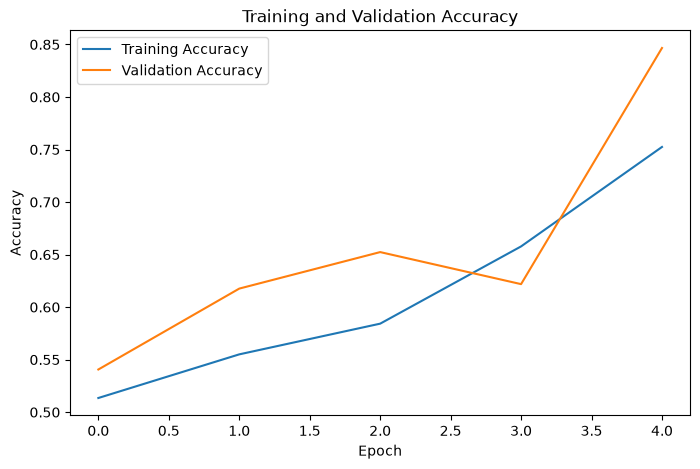

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Training and Validation Loss

Loss represents the error made by the model.

A decreasing training loss generally indicates that the model is learning from the training data.

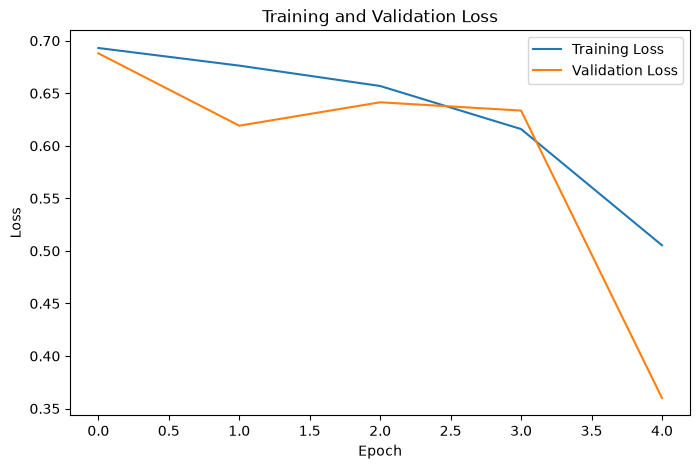

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Model Evaluation

After training, the model is evaluated using the test dataset.

The test dataset contains reviews that were not used during model training.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8484 - loss: 0.3606
Test Loss: 0.3606235980987549
Test Accuracy: 0.8483999967575073
Test Accuracy Percentage: 84.84 %


In [ ]:
predictions = model.predict(X_test_padded)

predicted_labels = (predictions >= 0.5).astype(int).flatten()

print("First 20 predicted labels:")
print(predicted_labels[:20])

print("\nFirst 20 actual labels:")
print(y_test.to_numpy()[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
First 20 predicted labels:
[0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1]

First 20 actual labels:
[0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 0 1]


## Confusion Matrix

A confusion matrix is used to compare the actual sentiment labels with the predicted sentiment labels.

It shows:

- True Negative
- False Positive
- False Negative
- True Positive

In [ ]:
cm = confusion_matrix(
    y_test,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4365  635]
 [ 881 4119]]


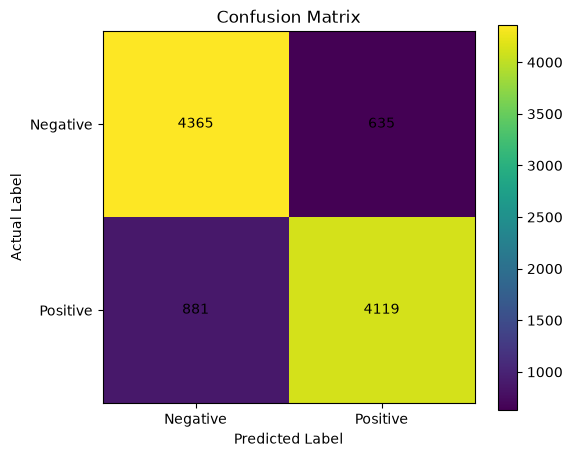

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

## Classification Report


In [ ]:
print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.87      0.85      5000
    Positive       0.87      0.82      0.84      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## Predict Sentiment of a New Review

The trained LSTM model can also predict the sentiment of a new movie review.

The new review is cleaned, converted into a numerical sequence, padded, and then passed to the trained model.

In [ ]:
def clean_new_review(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def predict_sentiment(review):
    cleaned_review = clean_new_review(review)

    sequence = tokenizer.texts_to_sequences([cleaned_review])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    prediction = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Prediction Score:", round(float(prediction), 4))
    print("Sentiment:", sentiment)

In [ ]:
predict_sentiment(
    "This movie was amazing. The story was excellent and the acting was very good."
)

Review: This movie was amazing. The story was excellent and the acting was very good.
Prediction Score: 0.8841
Sentiment: Positive


In [ ]:
predict_sentiment(
    "This movie was terrible. The story was boring and the acting was very disappointing."
)

Review: This movie was terrible. The story was boring and the acting was very disappointing.
Prediction Score: 0.0528
Sentiment: Negative


In [ ]:
predict_sentiment(
    "I really enjoyed this movie. It was entertaining and the performances were excellent."
)

Review: I really enjoyed this movie. It was entertaining and the performances were excellent.
Prediction Score: 0.8605
Sentiment: Positive
